Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scanning /content/drive/MyDrive/ColabNotebooks for ANY .ipynb file...

Found notebook: Tesi_DeepLearning.ipynb
Found notebook: Tesi_Demo_Riconoscimento.ipynb
Found notebook: Tesi_Parte2ML.ipynb
Dataset di training: (4424, 770)
Dataset di test finale (holdout): (1097, 770)
Dati di training: 4424 immagini
Dati di test finale (holdout): 1097 immagini

PARTE 2: ENSEMBLE METHODS

--- Creazione Voting Classifier ---
Ensemble composto da: SVM, Random Forest, MLP

--- Addestramento modelli singoli ---
1. Addestramento SVM...
   Accuratezza SVM: 96.63%
2. Addestramento Random Forest...
   Accuratezza Random Forest: 95.53%
3. Addestramento MLP...
   Accuratezza MLP: 96.63%

--- Addestramento Voting Ensemble ---
   Accuratezza Voting Ensemble: 96.72%

CONFRONTO FINALE
Modello                Accuracy  Precision     Recall         F1
--------------------------------------

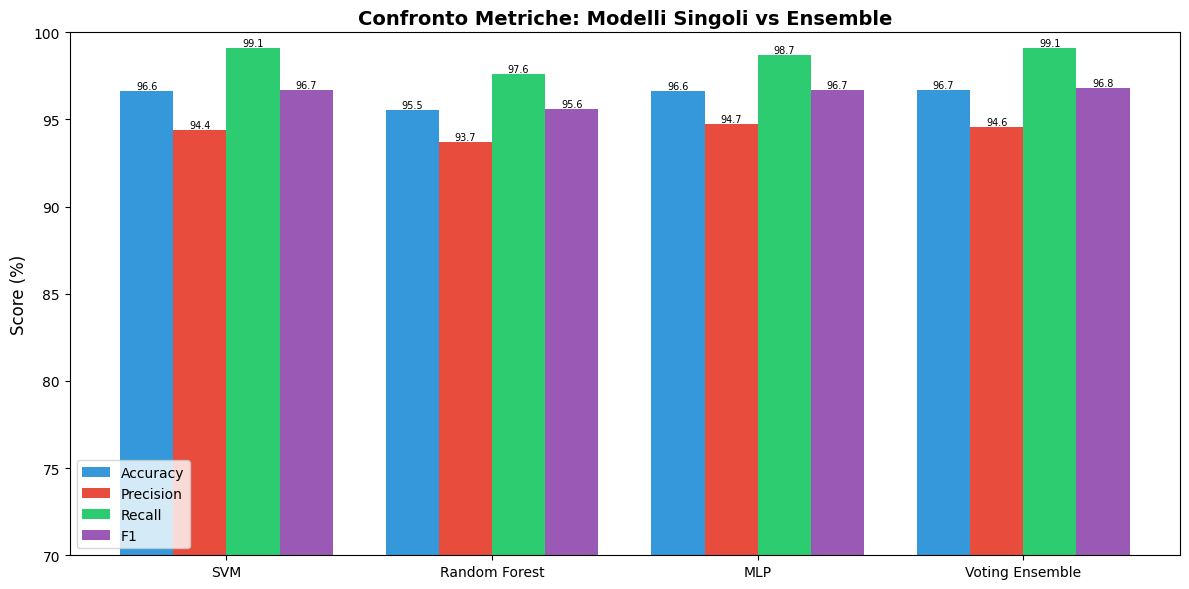


--- Report Dettagliato Voting Ensemble ---
              precision    recall  f1-score   support

       Reale       0.99      0.94      0.97       550
          AI       0.95      0.99      0.97       547

    accuracy                           0.97      1097
   macro avg       0.97      0.97      0.97      1097
weighted avg       0.97      0.97      0.97      1097



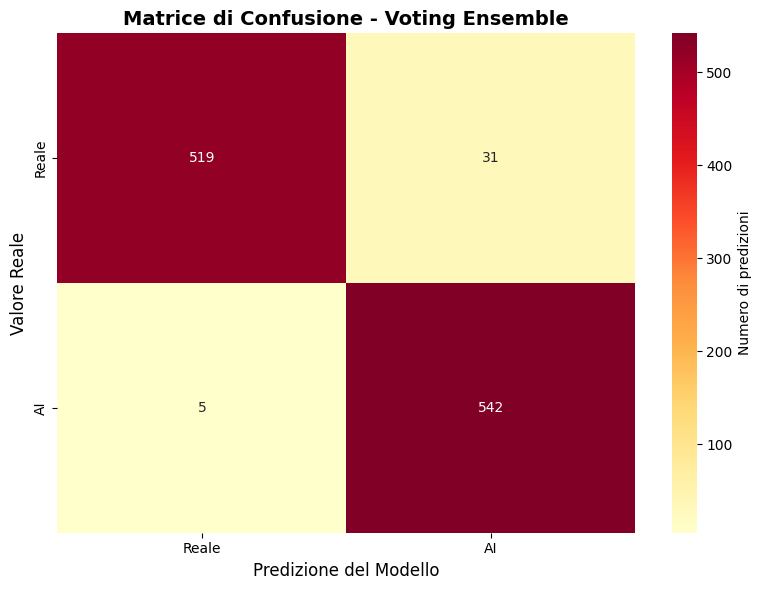


✓ Modello ensemble salvato in: /content/drive/MyDrive/Tesi/modello_voting_ensemble.pkl
✓ Risultati confronto salvati in: risultati_confronto_modelli.csv


In [30]:
# 1. Importiamo le librerie di Machine Learning classico
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier
from google.colab import drive
import os
import json
from sklearn.preprocessing import StandardScaler

# 2. Colleghiamo Google Drive
drive.mount('/content/drive')

# Base path
base_path = "/content/drive/MyDrive/ColabNotebooks"
found_files = []

print(f"Scanning {base_path} for ANY .ipynb file...\n")

if os.path.exists(base_path):
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(".ipynb"):
                full_path = os.path.join(root, file)
                found_files.append(full_path)
                print(f"Found notebook: {file}")
else:
    print(f"Directory {base_path} does not exist.")

# Helper function to read code
def extract_code_snippets(notebook_path, keywords):
    print(f"\n--- Analyzing {os.path.basename(notebook_path)} ---")
    try:
        with open(notebook_path, 'r', encoding='utf-8') as f:
            nb = json.load(f)

        for cell in nb['cells']:
            if cell['cell_type'] == 'code':
                source = "".join(cell['source'])
                # Check if any keyword is in the source code
                if any(k in source for k in keywords):
                    print(f"\n[Match found in {os.path.basename(notebook_path)}]:\n{source[:500]}...")
    except Exception as e:
        print(f"Error reading {notebook_path}: {e}")

# Training set: tutto TesiImages (4424 immagini)
filepath_train = '/content/drive/MyDrive/Tesi/Tesi_Images/dataset_features.csv'
df_train = pd.read_csv(filepath_train)
print(f"Dataset di training: {df_train.shape}")

# Test set finale: tutto ImmaginiTest (1097 immagini, mai viste)
filepath_test = '/content/drive/MyDrive/Tesi/ImmaginiTest/features_test.csv'
df_test = pd.read_csv(filepath_test)
print(f"Dataset di test finale (holdout): {df_test.shape}")

feature_cols = [c for c in df_train.columns if c.startswith('feature')]
X_train = df_train[feature_cols]
y_train = df_train['label']
X_test  = df_test[feature_cols]
y_test  = df_test['label']

print(f"Dati di training: {X_train.shape[0]} immagini")
print(f"Dati di test finale (holdout): {X_test.shape[0]} immagini")

# -------------------------------------------------------
# MODELLO 1: Support Vector Machine (SVM)
# È il modello classico per eccellenza per questo tipo di vettori
# -------------------------------------------------------
print("\n" + "="*60)
print("PARTE 2: ENSEMBLE METHODS")
print("="*60)

# -------------------------------------------------------
# Creiamo 4 classificatori diversi
# -------------------------------------------------------

# 1. SVM (quello che già usavi)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# 2. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,      # Numero di alberi
    max_depth=20,          # Profondità massima
    min_samples_split=5,
    random_state=42
)

# 3. Multi-Layer Perceptron (Neural Network classico)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),  # 3 layer nascosti
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,   # Ferma se non migliora
    validation_fraction=0.1
)

# -------------------------------------------------------
# Creiamo il VOTING CLASSIFIER
# -------------------------------------------------------
print("\n--- Creazione Voting Classifier ---")

# Lista di (nome, modello)
estimators = [
    ('svm', svm_model),
    ('rf', rf_model),
    ('mlp', mlp_model)
]

# Voting Classifier con voto "soft" (usa le probabilità)
voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft'  # 'soft' usa le probabilità, 'hard' usa voto maggioranza
)

print("Ensemble composto da: SVM, Random Forest, MLP")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------------------------------
# Addestramento di tutti i modelli
# -------------------------------------------------------
print("\n--- Addestramento modelli singoli ---")

# Dizionario per salvare i risultati
results = {}

# Addestra SVM
print("1. Addestramento SVM...")
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
results['SVM'] = {
    'accuracy':  accuracy_score(y_test, y_pred_svm),
    'precision': precision_score(y_test, y_pred_svm),
    'recall':    recall_score(y_test, y_pred_svm),
    'f1':        f1_score(y_test, y_pred_svm)
}
print(f"   Accuratezza SVM: {results['SVM']['accuracy']*100:.2f}%")

# Addestra Random Forest
print("2. Addestramento Random Forest...")
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
results['Random Forest'] = {
    'accuracy':  accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall':    recall_score(y_test, y_pred_rf),
    'f1':        f1_score(y_test, y_pred_rf)
}
print(f"   Accuratezza Random Forest: {results['Random Forest']['accuracy']*100:.2f}%")
# Addestra MLP
print("3. Addestramento MLP...")
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)
results['MLP'] = {
    'accuracy':  accuracy_score(y_test, y_pred_mlp),
    'precision': precision_score(y_test, y_pred_mlp),
    'recall':    recall_score(y_test, y_pred_mlp),
    'f1':        f1_score(y_test, y_pred_mlp)
}
print(f"   Accuratezza MLP: {results['MLP']['accuracy']*100:.2f}%")


# Addestra Voting Ensemble
print("\n--- Addestramento Voting Ensemble ---")
voting_clf.fit(X_train_scaled, y_train)
y_pred_voting = voting_clf.predict(X_test_scaled)
results['Voting Ensemble'] = {
    'accuracy':  accuracy_score(y_test, y_pred_voting),
    'precision': precision_score(y_test, y_pred_voting),
    'recall':    recall_score(y_test, y_pred_voting),
    'f1':        f1_score(y_test, y_pred_voting)
}
print(f"   Accuratezza Voting Ensemble: {results['Voting Ensemble']['accuracy']*100:.2f}%")

# -------------------------------------------------------
# CONFRONTO RISULTATI
# -------------------------------------------------------
print("\n" + "="*60)
print("CONFRONTO FINALE")
print("="*60)
print(f"{'Modello':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*60)
for nome, m in results.items():
    print(f"{nome:<20} {m['accuracy']*100:>9.2f}% {m['precision']*100:>9.2f}% {m['recall']*100:>9.2f}% {m['f1']*100:>9.2f}%")

# Grafico a barre per confronto
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results))
width = 0.2
metriche = ['accuracy', 'precision', 'recall', 'f1']
colori   = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
etichette = ['Accuracy', 'Precision', 'Recall', 'F1']

for i, (metrica, colore, etichetta) in enumerate(zip(metriche, colori, etichette)):
    valori = [results[m][metrica]*100 for m in results]
    bars = ax.bar(x + i*width, valori, width, label=etichetta, color=colore)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(list(results.keys()))
ax.set_ylim([70, 100])
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Confronto Metriche: Modelli Singoli vs Ensemble', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------------------
# REPORT DETTAGLIATO DELL'ENSEMBLE
# -------------------------------------------------------
print("\n--- Report Dettagliato Voting Ensemble ---")
print(classification_report(y_test, y_pred_voting, target_names=['Reale', 'AI']))

# Matrice di confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_voting)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Reale', 'AI'],
            yticklabels=['Reale', 'AI'],
            cbar_kws={'label': 'Numero di predizioni'})
plt.ylabel('Valore Reale', fontsize=12)
plt.xlabel('Predizione del Modello', fontsize=12)
plt.title('Matrice di Confusione - Voting Ensemble', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# SALVA IL MODELLO ENSEMBLE
# -------------------------------------------------------
import joblib
joblib.dump(scaler, '/content/drive/MyDrive/Tesi/scaler.pkl')

ensemble_path = '/content/drive/MyDrive/Tesi/modello_voting_ensemble.pkl'
joblib.dump(voting_clf, ensemble_path)
print(f"\n✓ Modello ensemble salvato in: {ensemble_path}")

# Salva anche i risultati
results_df = pd.DataFrame({
    'Modello': list(results.keys()),
    'Accuratezza': list(results.values())
})
results_df.to_csv('/content/drive/MyDrive/Tesi/risultati_confronto_modelli.csv', index=False)
print("✓ Risultati confronto salvati in: risultati_confronto_modelli.csv")

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import joblib

# Definiamo il percorso dove salvare il modello
model_path = '/content/drive/MyDrive/Tesi/modello_svm_clip.pkl'

# Salviamo l'SVM addestrata
joblib.dump(svm_model, model_path)

print(f"Modello salvato con successo in: {model_path}")
print("Ora puoi usare questo file per classificare nuove immagini!")

Modello salvato con successo in: /content/drive/MyDrive/Tesi/modello_svm_clip.pkl
Ora puoi usare questo file per classificare nuove immagini!


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Print shapes to confirm
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (4424, 768)
Testing set shape: (1097, 768)


Class Counts: 0=2897, 1=2624
Percentages: Real 52.47%, AI 47.53%


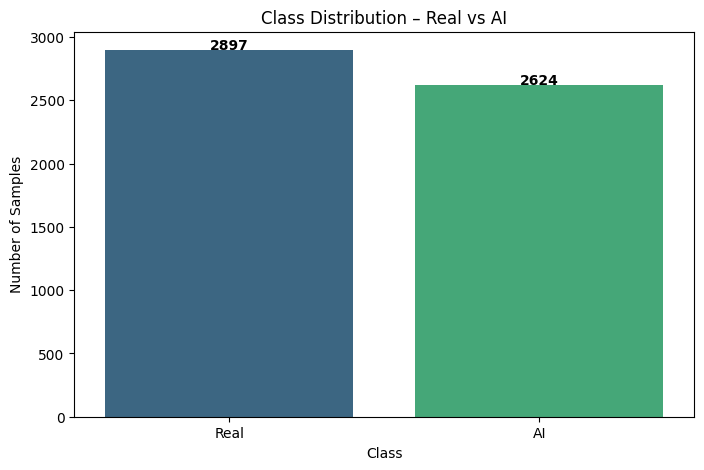

In [34]:
df_all = pd.concat([df_train, df_test], ignore_index=True)

feature_cols = [c for c in df_train.columns if c.startswith('feature')]
class_counts = df_all['label'].value_counts().sort_index()

total_samples = len(df_all)
percentage_real = class_counts[0] / total_samples * 100
percentage_ai   = class_counts[1] / total_samples * 100

print(f"Class Counts: 0={class_counts[0]}, 1={class_counts[1]}")
print(f"Percentages: Real {percentage_real:.2f}%, AI {percentage_ai:.2f}%")

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df_all, palette='viridis', hue='label', legend=False)
plt.xticks(ticks=[0,1], labels=['Real', 'AI'])
plt.title('Class Distribution – Real vs AI')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
for i, count in enumerate(class_counts):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')
plt.show()


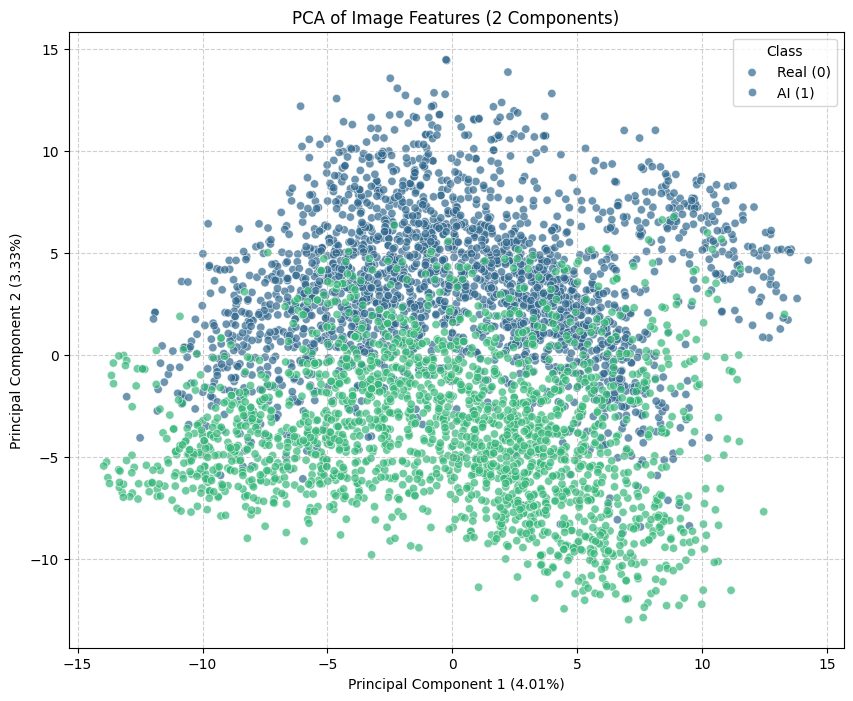

Explained Variance Ratio: [0.04006814 0.0332953 ]
Total Explained Variance: 7.34%


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data
feature_cols = [c for c in df_train.columns if c.startswith('feature_')]
X = df_train[feature_cols]
y = df_train['label']

# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Create DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['label'] = y

# 5. Visualize
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='label',
    palette='viridis',
    data=pca_df,
    alpha=0.7
)
plt.title('PCA of Image Features (2 Components)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.legend(title='Class', labels=['Real (0)', 'AI (1)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Display explained variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_)*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


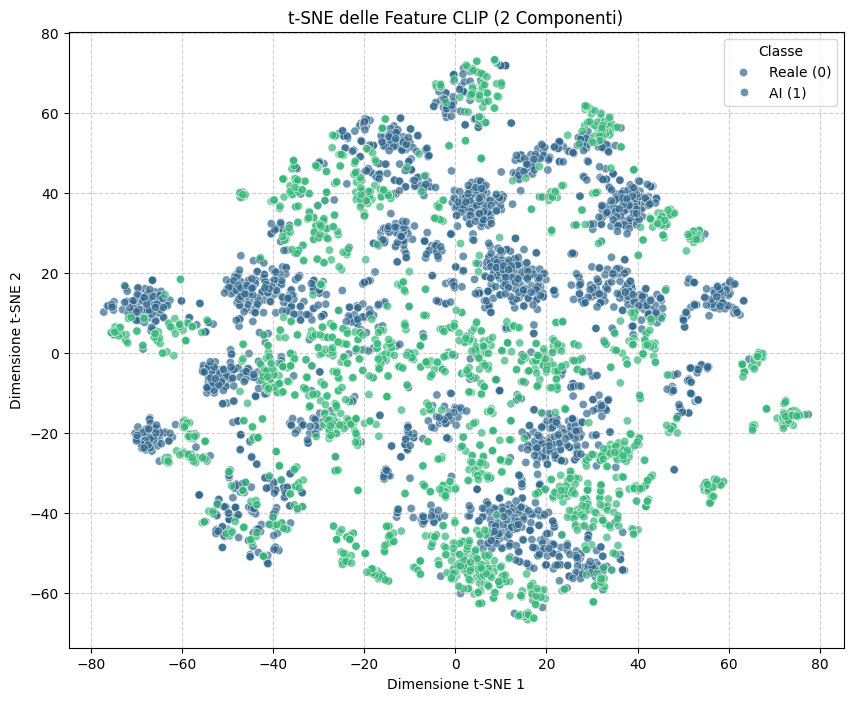

In [36]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepara i dati
feature_cols = [c for c in df_train.columns if c.startswith('feature')]
X = df_train[feature_cols]
y = df_train['label']

# 2. Standardizza le feature (uguale alla PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Applica t-SNE (riduci a 2 dimensioni)
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 4. Crea DataFrame per il plot
tsne_df = pd.DataFrame(data=X_tsne, columns=['Dim1', 'Dim2'])
tsne_df['label'] = y.values

# 5. Visualizza
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='label',
    palette='viridis',
    data=tsne_df,
    alpha=0.7
)
plt.title('t-SNE delle Feature CLIP (2 Componenti)')
plt.xlabel('Dimensione t-SNE 1')
plt.ylabel('Dimensione t-SNE 2')
plt.legend(title='Classe', labels=['Reale (0)', 'AI (1)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
import numpy as np

# 1. Re-instantiate base models with parameters from instructions
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
mlp_model = MLPClassifier(hidden_layer_sizes=(512, 256, 128), max_iter=500, random_state=42)

# 2. Create Voting Classifier
estimators = [('svm', svm_model), ('rf', rf_model), ('mlp', mlp_model)]
voting_clf = VotingClassifier(estimators=estimators, voting='soft')

# 3. Create Pipeline (Scaling + Classifier)
# Scaling is crucial for SVM and Neural Networks within CV to prevent leakage
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', voting_clf)
])

# 4. Perform 5-fold Cross-Validation
print("Running 5-Fold Cross-Validation on Voting Classifier (with Scaling)...")
# X and y are reused from the previous PCA step
cv_scores = cross_val_score(clf_pipeline, X, y, cv=5, scoring='accuracy')

# 5. Print Results
print("\n--- Cross-Validation Accuracy per Fold ---")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score*100:.2f}%")

mean_acc = cv_scores.mean()
std_acc = cv_scores.std()

print(f"\nMean Accuracy: {mean_acc*100:.2f}%")
print(f"Standard Deviation: {std_acc*100:.2f}%")

Running 5-Fold Cross-Validation on Voting Classifier (with Scaling)...

--- Cross-Validation Accuracy per Fold ---
Fold 1: 98.19%
Fold 2: 98.08%
Fold 3: 92.20%
Fold 4: 94.12%
Fold 5: 91.29%

Mean Accuracy: 94.78%
Standard Deviation: 2.89%


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier

# 1. Initialize StandardScaler
scaler = StandardScaler()

# 2. Fit on training set and transform
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform test set
X_test_scaled = scaler.transform(X_test)

# 4. Instantiate Classifiers
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
mlp_model = MLPClassifier(hidden_layer_sizes=(512, 256, 128), max_iter=500,
                          random_state=42, early_stopping=True)

# 5. Instantiate Voting Classifier
estimators = [
    ('svm', svm_model),
    ('rf', rf_model),
    ('mlp', mlp_model)
]

# 6. Train the model
print("Training Voting Classifier on scaled data...")
voting_clf.fit(X_train_scaled, y_train)

# 7. Completion message
print("Training complete!")

Training Voting Classifier on scaled data...
Training complete!


Test Set Accuracy: 96.72%

--- Classification Report ---
              precision    recall  f1-score   support

    Real (0)       0.99      0.94      0.97       550
      AI (1)       0.95      0.99      0.97       547

    accuracy                           0.97      1097
   macro avg       0.97      0.97      0.97      1097
weighted avg       0.97      0.97      0.97      1097



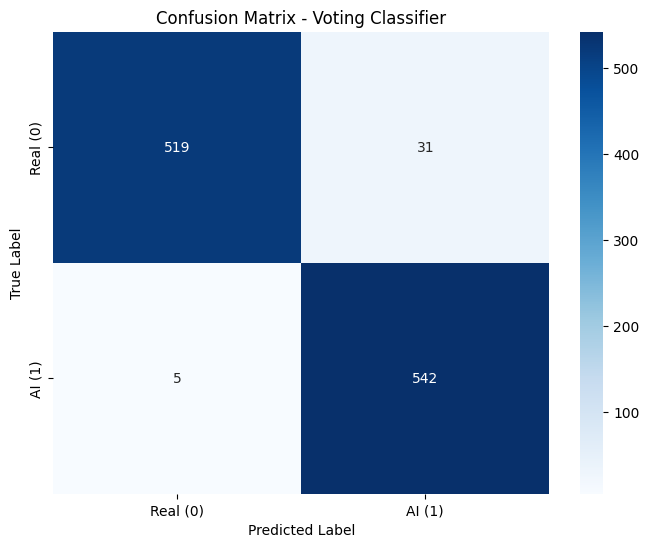

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict on test set
y_pred = voting_clf.predict(X_test_scaled)

# 2. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy*100:.2f}%")

# 3. Print Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Real (0)', 'AI (1)']))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'AI (1)'],
            yticklabels=['Real (0)', 'AI (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Voting Classifier')
plt.show()

In [40]:
import joblib

# Define paths
scaler_path = '/content/drive/MyDrive/Tesi/scaler.pkl'
model_path = '/content/drive/MyDrive/Tesi/modello_voting_ensemble.pkl'

# Save scaler and model
joblib.dump(scaler, scaler_path)
joblib.dump(voting_clf, model_path)

print(f"✓ Scaler saved to: {scaler_path}")
print(f"✓ Voting Ensemble model saved to: {model_path}")

✓ Scaler saved to: /content/drive/MyDrive/Tesi/scaler.pkl
✓ Voting Ensemble model saved to: /content/drive/MyDrive/Tesi/modello_voting_ensemble.pkl


In [41]:
import joblib
import os

# Define paths
model_path = '/content/drive/MyDrive/Tesi/modello_voting_ensemble.pkl'
scaler_path = '/content/drive/MyDrive/Tesi/scaler.pkl'

print(f"Attempting to load artifacts from:\n- Model: {model_path}\n- Scaler: {scaler_path}")

# Load artifacts
try:
    loaded_model = joblib.load(model_path)
    loaded_scaler = joblib.load(scaler_path)
    print("\n\u2713 Successfully loaded Voting Classifier model and StandardScaler!")
except Exception as e:
    print(f"\nError loading artifacts: {e}")

Attempting to load artifacts from:
- Model: /content/drive/MyDrive/Tesi/modello_voting_ensemble.pkl
- Scaler: /content/drive/MyDrive/Tesi/scaler.pkl

✓ Successfully loaded Voting Classifier model and StandardScaler!


In [42]:
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Convert X_test to NumPy array to avoid potential feature name warnings during scaling
# (This ensures the scaler treats input as a raw matrix, bypassing feature name checks)
X_test_np = X_test.values

# 2. Scale the data using the loaded scaler
X_test_scaled_loaded = loaded_scaler.transform(X_test_np)

# 3. Predict using the loaded model
y_pred_loaded = loaded_model.predict(X_test_scaled_loaded)

# 4. Calculate accuracy
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)

print(f"Verification Prediction Accuracy: {accuracy_loaded*100:.2f}%")

# 5. Confirm consistency
if accuracy_loaded > 0.90:
    print("\u2713 Verification Successful: The loaded model reproduces high accuracy (>90%).")
else:
    print("\u26a0 Verification Warning: Accuracy is lower than expected. Check data alignment.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Verification Prediction Accuracy: 96.72%
✓ Verification Successful: The loaded model reproduces high accuracy (>90%).


In [43]:
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Use X_test DataFrame directly to match feature names expected by the scaler
# The scaler was fitted on a DataFrame, so passing a DataFrame here avoids the "no valid feature names" warning.
X_test_scaled_loaded = loaded_scaler.transform(X_test)

# 2. Predict using the loaded model
y_pred_loaded = loaded_model.predict(X_test_scaled_loaded)

# 3. Calculate accuracy
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)

print(f"Verification Prediction Accuracy: {accuracy_loaded*100:.2f}%")

# 4. Confirm consistency
if accuracy_loaded > 0.90:
    print("\u2713 Verification Successful: The loaded model reproduces high accuracy (>90%).")
else:
    print("\u26a0 Verification Warning: Accuracy is lower than expected. Check data alignment.")

Verification Prediction Accuracy: 96.72%
✓ Verification Successful: The loaded model reproduces high accuracy (>90%).
